# Stage 7 — Revenue Forecasting

## Purpose
Translate model churn probabilities into concrete business value.
Answer the question every stakeholder cares about:
"How much monthly revenue are we at risk of losing — and who do we call first?"

## Core Formula
Revenue at Risk (per customer) = MonthlyCharges × Churn Probability

## Key Outputs
1. Total monthly revenue at risk across all customers
2. Customer risk tier segmentation (High / Medium / Low)
3. Top 20 highest-value customers at risk — the priority call list
4. Retention ROI forecast — how much revenue a campaign could save
5. Business recommendations with specific action items

## Model Used
Logistic Regression — selected for highest Recall (fewest missed churners)
which is the correct optimisation for this asymmetric cost problem.

In [1]:
# Import all libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.facecolor'] = 'white'

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'
FIGURES_PATH   = '../reports/figures/'

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load all required data and the best model

X_test       = pd.read_csv(f'{PROCESSED_PATH}X_test.csv')
y_test       = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()
X_train      = pd.read_csv(f'{PROCESSED_PATH}X_train.csv')
y_train      = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()
df_clean     = pd.read_csv(f'{PROCESSED_PATH}churn_cleaned.csv')

# Load Logistic Regression — our selected best model (highest recall)
lr_model = joblib.load(f'{MODELS_PATH}logistic_regression.pkl')

print("Data and model loaded:")
print(f"  X_test shape     : {X_test.shape}")
print(f"  Full dataset     : {df_clean.shape}")
print(f"  Model type       : {type(lr_model).__name__}")

Data and model loaded:
  X_test shape     : (1407, 30)
  Full dataset     : (7032, 20)
  Model type       : LogisticRegression


In [3]:
# Generate churn probability scores for all test customers 

# Get churn probabilities from the model
churn_proba = lr_model.predict_proba(X_test)[:,1]
churn_pred  = lr_model.predict(X_test)

print(f"Churn probability scores generated for {len(churn_proba):,} customers")
print(f"\nProbability distribution summary:")
print(f"  Min    : {churn_proba.min():.4f}")
print(f"  Max    : {churn_proba.max():.4f}")
print(f"  Mean   : {churn_proba.mean():.4f}")
print(f"  Median : {np.median(churn_proba):.4f}")
print(f"  Std    : {churn_proba.std():.4f}")


Churn probability scores generated for 1,407 customers

Probability distribution summary:
  Min    : 0.0047
  Max    : 0.9344
  Mean   : 0.4213
  Median : 0.4128
  Std    : 0.3038


In [4]:
# Reconstruct the test set with original dollar values

from sklearn.model_selection import train_test_split

# Re-create the exact same split as Stage 4
_, df_test_orig = train_test_split(
    df_clean,
    test_size    = 0.2,
    random_state = 42,
    stratify     = df_clean['Churn']
)
df_test_orig = df_test_orig.reset_index(drop=True)

# Build the master forecasting dataframe
forecast_df = pd.DataFrame({
    'churn_probability'  : churn_proba,
    'predicted_churn'    : churn_pred,
    'actual_churn'       : y_test.values,
    'MonthlyCharges'     : df_test_orig['MonthlyCharges'].values,
    'TotalCharges'       : df_test_orig['TotalCharges'].values,
    'tenure'             : df_test_orig['tenure'].values,
    'Contract'           : df_test_orig['Contract'].values,
})

# Revenue at Risk = MonthlyCharges × Churn Probability
forecast_df['revenue_at_risk'] = (
    forecast_df['MonthlyCharges'] * forecast_df['churn_probability']
)

print(f"Forecast dataframe built: {forecast_df.shape}")
print()
print("Sample rows:")
print(forecast_df[['churn_probability','MonthlyCharges',
                    'revenue_at_risk','actual_churn']].head(8).round(2))

Forecast dataframe built: (1407, 8)

Sample rows:
   churn_probability  MonthlyCharges  revenue_at_risk  actual_churn
0               0.05           75.95             3.88             0
1               0.78           78.55            61.65             0
2               0.01           20.10             0.29             0
3               0.40           20.65             8.28             1
4               0.23          105.15            24.49             0
5               0.72          105.90            76.46             1
6               0.07           24.15             1.76             0
7               0.35           20.65             7.20             0


In [5]:
# Calculate total revenue at risk

total_monthly_revenue = forecast_df['MonthlyCharges'].sum()
total_revenue_at_risk = forecast_df['revenue_at_risk'].sum()
pct_at_risk           = (total_revenue_at_risk / total_monthly_revenue) * 100

# Customers predicted to churn (hard threshold = 0.5)
n_predicted_churners  = forecast_df['predicted_churn'].sum()
revenue_predicted_lost = forecast_df.loc[
    forecast_df['predicted_churn'] == 1, 'MonthlyCharges'
].sum()

print("=" * 58)
print("  REVENUE AT RISK — EXECUTIVE SUMMARY")
print("=" * 58)
print(f"""
  TEST SET CUSTOMERS       : {len(forecast_df):,}
  TOTAL MONTHLY REVENUE    : ${total_monthly_revenue:,.2f}

  EXPECTED REVENUE AT RISK : ${total_revenue_at_risk:,.2f}/month
  (weighted by churn probability per customer)

  % OF REVENUE AT RISK     : {pct_at_risk:.1f}%

  CUSTOMERS FLAGGED (>0.5) : {int(n_predicted_churners):,}
  REVENUE FROM FLAGGED     : ${revenue_predicted_lost:,.2f}/month

  ANNUAL PROJECTION        : ${total_revenue_at_risk * 12:,.2f}/year
  (if no retention action is taken)
""")
print("=" * 58)

  REVENUE AT RISK — EXECUTIVE SUMMARY

  TEST SET CUSTOMERS       : 1,407
  TOTAL MONTHLY REVENUE    : $90,039.85

  EXPECTED REVENUE AT RISK : $42,802.57/month
  (weighted by churn probability per customer)

  % OF REVENUE AT RISK     : 47.5%

  CUSTOMERS FLAGGED (>0.5) : 606
  REVENUE FROM FLAGGED     : $45,774.55/month

  ANNUAL PROJECTION        : $513,630.85/year
  (if no retention action is taken)



In [6]:
# Assign risk tiers and analyse each tier

# High risk    : probability > 0.70    -  intervene immediately
# Medium risk  : probability 0.40 - 0.70 - monitor and nurture
# Low risk     : probability < 0.40 - no immediate action needed

def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.40:
        return 'Medium'
    else:
        return 'Low'
    
forecast_df['risk_tier'] = forecast_df['churn_probability'].apply(assign_risk_tier)

# Summarise each tier
tier_summary = forecast_df.groupby('risk_tier').agg(
        customers        = ('churn_probability', 'count'),
        avg_probability  = ('churn_probability', 'mean'),
        avg_monthly      = ('MonthlyCharges',    'mean'),
        total_monthly    = ('MonthlyCharges',    'sum'),
        total_at_risk    = ('revenue_at_risk',   'sum'),
        actual_churners  = ('actual_churn',      'sum')
    ).round(2)

# Add percentage columns
tier_summary['pct_of_customers'] = (
        tier_summary['customers']/len(forecast_df) * 100
    ).round(1)
tier_summary['pct_of_risk'] = (
        tier_summary['total_at_risk']/total_revenue_at_risk * 100
    ).round(1)

# Reorder for display: High → Medium → Low
tier_order   = ['High', 'Medium','Low']
tier_summary = tier_summary.reindex(tier_order) 

print("=" * 70)
print("  CUSTOMER RISK TIER SEGMENTATION")
print("=" * 70)
print(tier_summary.to_string())
print("=" * 70)
print()
print("KEY INSIGHT: What fraction of total revenue risk sits in the")
print("High tier? That percentage tells you how concentrated the problem is.")



  CUSTOMER RISK TIER SEGMENTATION
           customers  avg_probability  avg_monthly  total_monthly  total_at_risk  actual_churners  pct_of_customers  pct_of_risk
risk_tier                                                                                                                       
High             378             0.81        78.69       29744.40       24153.86              232              26.9         56.4
Medium           343             0.55        65.51       22471.15       12565.74               94              24.4         29.4
Low              686             0.14        55.14       37824.30        6082.97               48              48.8         14.2

KEY INSIGHT: What fraction of total revenue risk sits in the
High tier? That percentage tells you how concentrated the problem is.


Most of the risk is concentrated in a small group of customers. About 56% of the total revenue risk comes from just 27% of customers in the high-risk group. This means we should focus on these customers first to get the biggest impact. The model is working well because high-risk customers are much more likely to churn than low-risk ones.

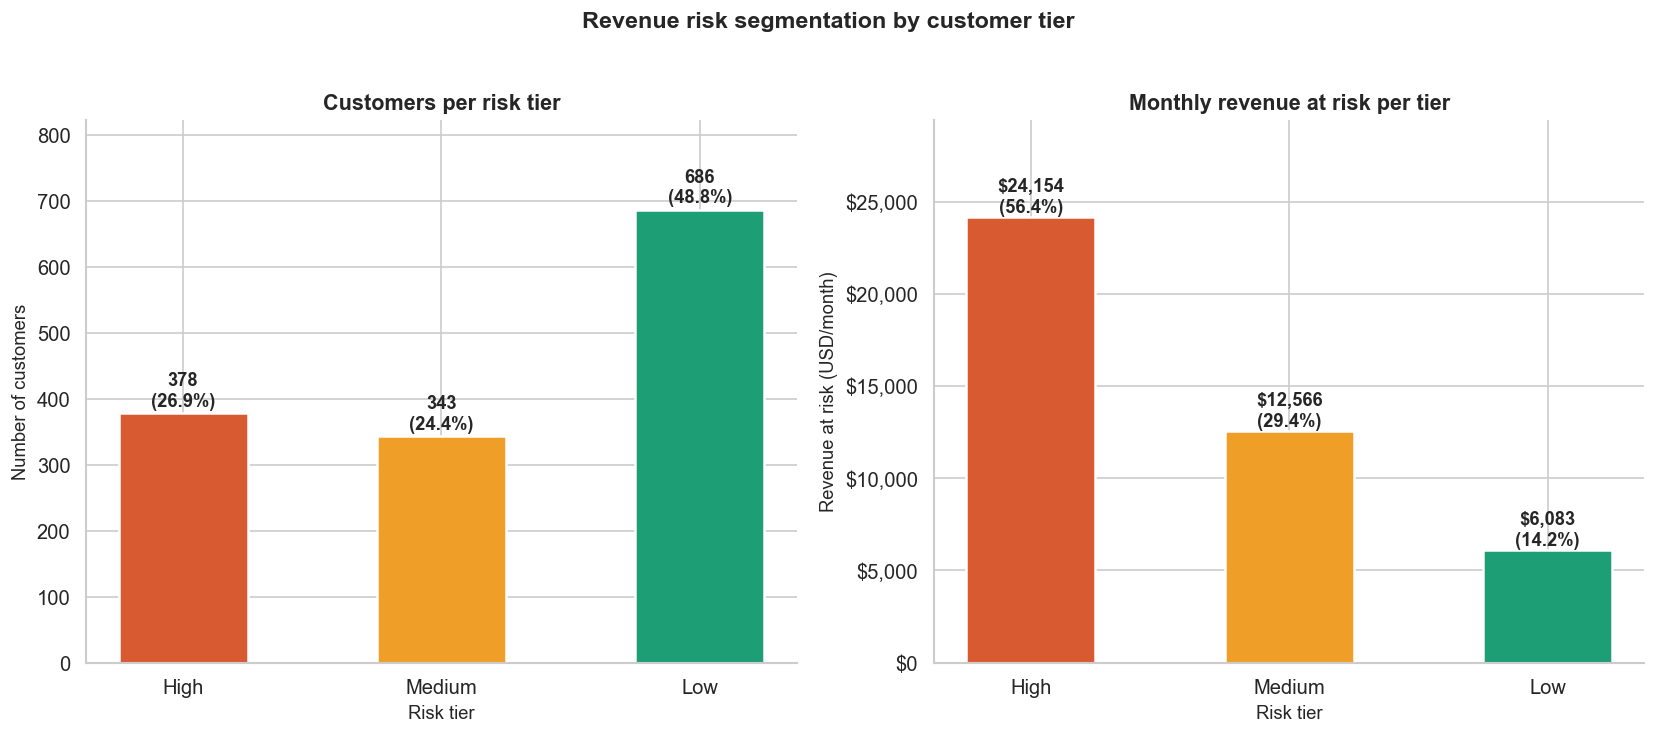

Saved: 16_revenue_risk_tiers.png


In [7]:
# Risk tier revenue visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tier_colors = {'High': '#D85A30', 'Medium': '#EF9F27', 'Low': '#1D9E75'}
colors_list = [tier_colors[t] for t in tier_order]

# ── Chart 1: Customer count per tier ──
ax1 = axes[0]
counts = [tier_summary.loc[t, 'customers'] for t in tier_order]
bars   = ax1.bar(tier_order, counts, color=colors_list,
                 width=0.5, edgecolor='white', linewidth=1.5)

for bar, count, pct in zip(bars, counts,
    [tier_summary.loc[t, 'pct_of_customers'] for t in tier_order]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{int(count):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_title('Customers per risk tier', fontsize=13, fontweight='bold')
ax1.set_xlabel('Risk tier', fontsize=11)
ax1.set_ylabel('Number of customers', fontsize=11)
ax1.set_ylim(0, max(counts) * 1.2)
sns.despine(ax=ax1)

# ── Chart 2: Revenue at risk per tier ──
ax2 = axes[1]
rev_at_risk = [tier_summary.loc[t, 'total_at_risk'] for t in tier_order]
bars2       = ax2.bar(tier_order, rev_at_risk, color=colors_list,
                      width=0.5, edgecolor='white', linewidth=1.5)

for bar, rev, pct in zip(bars2, rev_at_risk,
    [tier_summary.loc[t, 'pct_of_risk'] for t in tier_order]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             f'${rev:,.0f}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('Monthly revenue at risk per tier', fontsize=13, fontweight='bold')
ax2.set_xlabel('Risk tier', fontsize=11)
ax2.set_ylabel('Revenue at risk (USD/month)', fontsize=11)
ax2.set_ylim(0, max(rev_at_risk) * 1.22)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=ax2)

fig.suptitle('Revenue risk segmentation by customer tier',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}16_revenue_risk_tiers.png', bbox_inches='tight')
plt.show()
print("Saved: 16_revenue_risk_tiers.png")

In [8]:
# Build top 20 priority customer list 

top_20 = (forecast_df
          .sort_values('revenue_at_risk', ascending=False)
          .head(20)
          .reset_index(drop=True))
display_cols = [
    'churn_probability',
    'MonthlyCharges',
    'revenue_at_risk',
    'tenure',
    'Contract',
    'risk_tier',
    'actual_churn'
]

print("TOP 20 PRIORITY CUSTOMERS - Ranked by Revenue at Risk")
print("=" * 75)
print(top_20[display_cols].to_string())
print("=" * 75)
print(f"\nTotal monthly revenue at risk from top 20 : "
      f"${top_20['revenue_at_risk'].sum():,.2f}")
print(f"As % of total revenue at risk             : "
      f"{top_20['revenue_at_risk'].sum()/total_revenue_at_risk*100:.1f}%")

TOP 20 PRIORITY CUSTOMERS - Ranked by Revenue at Risk
    churn_probability  MonthlyCharges  revenue_at_risk  tenure        Contract risk_tier  actual_churn
0            0.902738          104.85        94.652096      14  Month-to-month      High             1
1            0.881782          106.70        94.086157      12  Month-to-month      High             1
2            0.893189          105.30        94.052794       6  Month-to-month      High             1
3            0.918632          100.95        92.735857       3  Month-to-month      High             1
4            0.887377          104.35        92.597796      21  Month-to-month      High             0
5            0.924424           99.25        91.749058       7  Month-to-month      High             1
6            0.904106          100.75        91.088723      11  Month-to-month      High             1
7            0.871949          104.25        90.900720      24  Month-to-month      High             1
8            0.8619

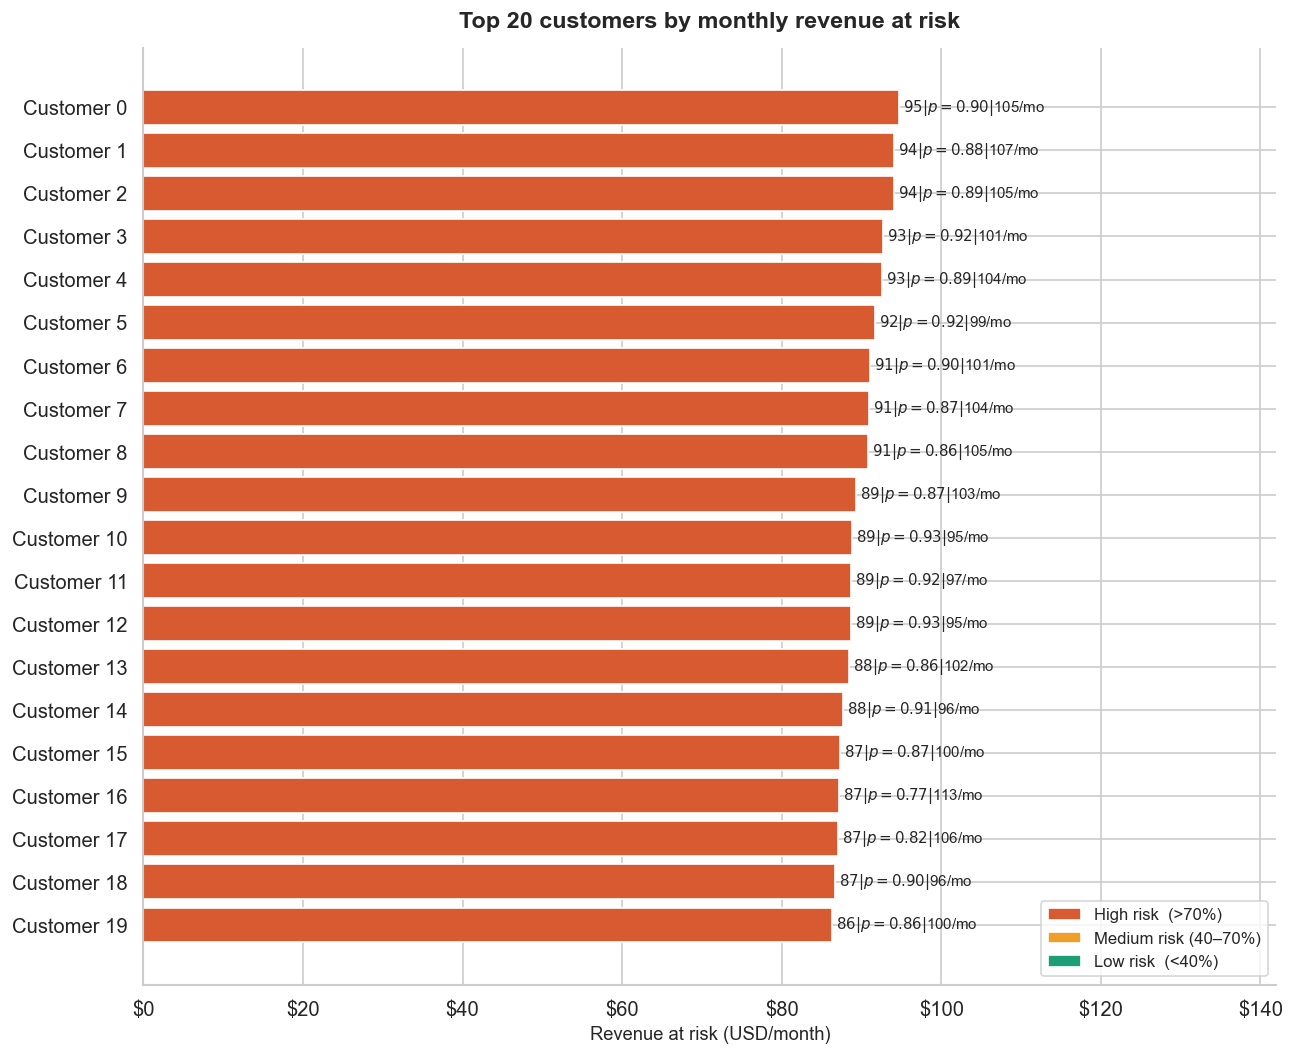

Saved: 17_top20_priority_customers.png


In [9]:
# Visualise the top 20 as a horizontal bar chart

fig, ax = plt.subplots(figsize=(11, 9))

bar_colors = [tier_colors.get(t, '#888780')
              for t in top_20['risk_tier']]

bars = ax.barh(
    [f"Customer {i}" for i in top_20.index],
    top_20['revenue_at_risk'],
    color    = bar_colors,
    edgecolor = 'white',
    linewidth = 1
)

# Label each bar with the key numbers
for bar, row in zip(bars, top_20.itertuples()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'${row.revenue_at_risk:.0f}  |  '
            f'p={row.churn_probability:.2f}  |  '
            f'${row.MonthlyCharges:.0f}/mo',
            va='center', fontsize=9)

# Legend for risk tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='High risk  (>70%)'),
    Patch(facecolor='#EF9F27', label='Medium risk (40–70%)'),
    Patch(facecolor='#1D9E75', label='Low risk  (<40%)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

ax.set_title('Top 20 customers by monthly revenue at risk',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Revenue at risk (USD/month)', fontsize=11)
ax.invert_yaxis()   # highest risk at the top
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.set_xlim(0, top_20['revenue_at_risk'].max() * 1.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}17_top20_priority_customers.png', bbox_inches='tight')
plt.show()
print("Saved: 17_top20_priority_customers.png")

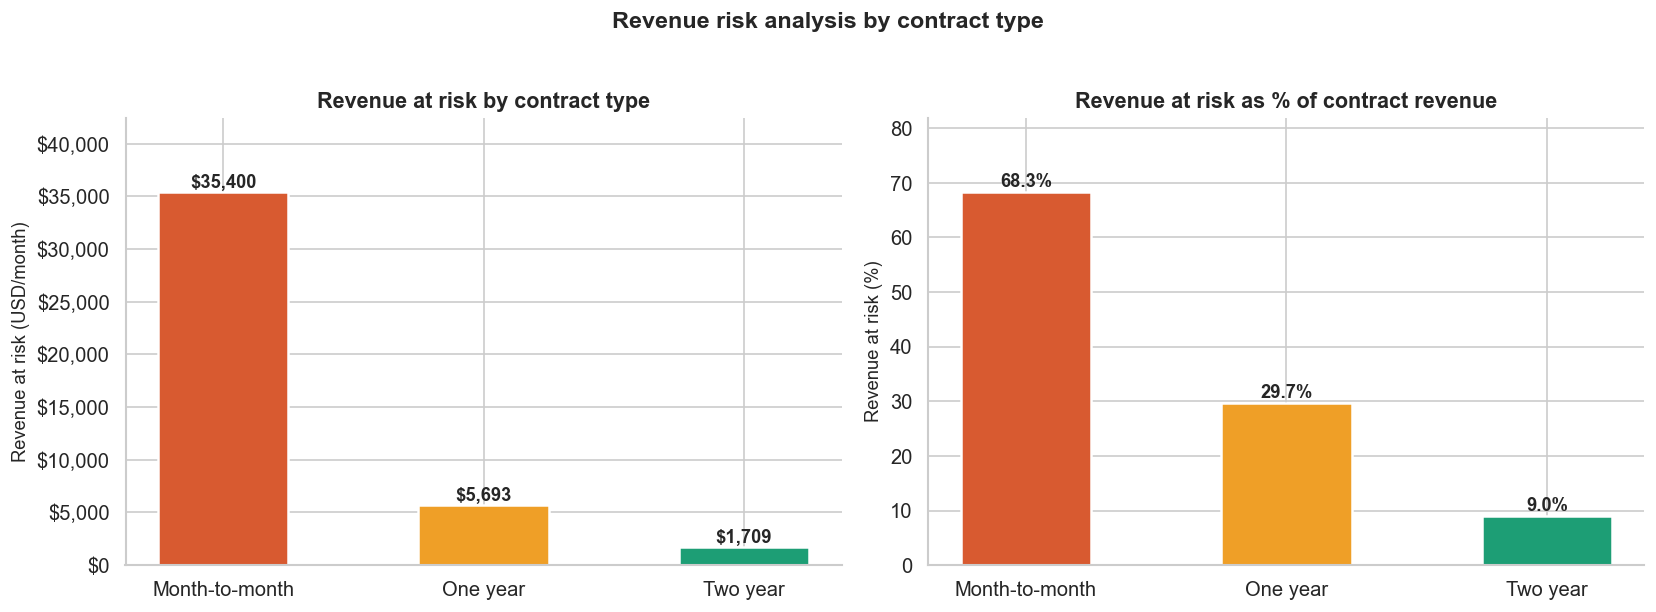

Saved: 18_revenue_by_contract.png


In [10]:
# Cell 10 — Revenue at risk broken down by Contract type


contract_risk = forecast_df.groupby('Contract').agg(
    customers    = ('churn_probability', 'count'),
    avg_prob     = ('churn_probability', 'mean'),
    total_risk   = ('revenue_at_risk',   'sum'),
    total_revenue = ('MonthlyCharges',   'sum')
).round(2)

contract_risk['risk_pct_of_revenue'] = (
    contract_risk['total_risk'] / contract_risk['total_revenue'] * 100
).round(1)

contract_risk = contract_risk.sort_values('total_risk', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_colors = ['#D85A30', '#EF9F27', '#1D9E75']

# ── Chart 1: Total revenue at risk by contract ──
ax1 = axes[0]
bars = ax1.bar(contract_risk.index,
               contract_risk['total_risk'],
               color=contract_colors, width=0.5,
               edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, contract_risk['total_risk']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'${val:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_title('Revenue at risk by contract type',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue at risk (USD/month)', fontsize=11)
ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylim(0, contract_risk['total_risk'].max() * 1.2)
sns.despine(ax=ax1)

# ── Chart 2: Risk as % of that contract's total revenue ──
ax2 = axes[1]
bars2 = ax2.bar(contract_risk.index,
                contract_risk['risk_pct_of_revenue'],
                color=contract_colors, width=0.5,
                edgecolor='white', linewidth=1.5)

for bar, val in zip(bars2, contract_risk['risk_pct_of_revenue']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('Revenue at risk as % of contract revenue',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue at risk (%)', fontsize=11)
ax2.set_ylim(0, contract_risk['risk_pct_of_revenue'].max() * 1.2)
sns.despine(ax=ax2)

fig.suptitle('Revenue risk analysis by contract type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}18_revenue_by_contract.png', bbox_inches='tight')
plt.show()
print("Saved: 18_revenue_by_contract.png")

In [11]:
# Model retention campaign ROI at different success rates

# For each retention rate (10% to 90%), we calculate:
# Revenue saved = retention_rate × total high-risk revenue at risk
# We then subtract a campaign cost assumption ($30 per contacted customer)
# to get NET savings.

high_risk_df          = forecast_df[forecast_df['risk_tier'] == 'High']
n_high_risk           = len(high_risk_df)
high_risk_revenue     = high_risk_df['revenue_at_risk'].sum()
campaign_cost_per_customer = 30   # USD — conservative estimate

retention_rates    = np.arange(0.10, 0.95, 0.05)
gross_revenue_saved = retention_rates * high_risk_revenue
campaign_costs      = n_high_risk * campaign_cost_per_customer
net_revenue_saved   = gross_revenue_saved - campaign_costs

roi_df = pd.DataFrame({
    'Retention Rate (%)' : (retention_rates * 100).round(0).astype(int),
    'Gross Saved ($/mo)' : gross_revenue_saved.round(2),
    'Campaign Cost ($)'  : campaign_costs,
    'Net Saved ($/mo)'   : net_revenue_saved.round(2),
    'Annual Net ($)'     : (net_revenue_saved * 12).round(2)
})

print(f"High-risk customers targeted : {n_high_risk:,}")
print(f"Their total revenue at risk  : ${high_risk_revenue:,.2f}/month")
print(f"Campaign cost assumption     : ${campaign_cost_per_customer}/customer")
print(f"Total campaign cost          : ${campaign_costs:,.2f} (one-time)")
print()
print("Retention ROI forecast:")
print(roi_df.to_string(index=False))

High-risk customers targeted : 378
Their total revenue at risk  : $24,153.86/month
Campaign cost assumption     : $30/customer
Total campaign cost          : $11,340.00 (one-time)

Retention ROI forecast:
 Retention Rate (%)  Gross Saved ($/mo)  Campaign Cost ($)  Net Saved ($/mo)  Annual Net ($)
                 10             2415.39              11340          -8924.61      -107095.36
                 15             3623.08              11340          -7716.92       -92603.05
                 20             4830.77              11340          -6509.23       -78110.73
                 25             6038.47              11340          -5301.53       -63618.41
                 30             7246.16              11340          -4093.84       -49126.09
                 35             8453.85              11340          -2886.15       -34633.78
                 40             9661.55              11340          -1678.45       -20141.46
                 45            10869.24            

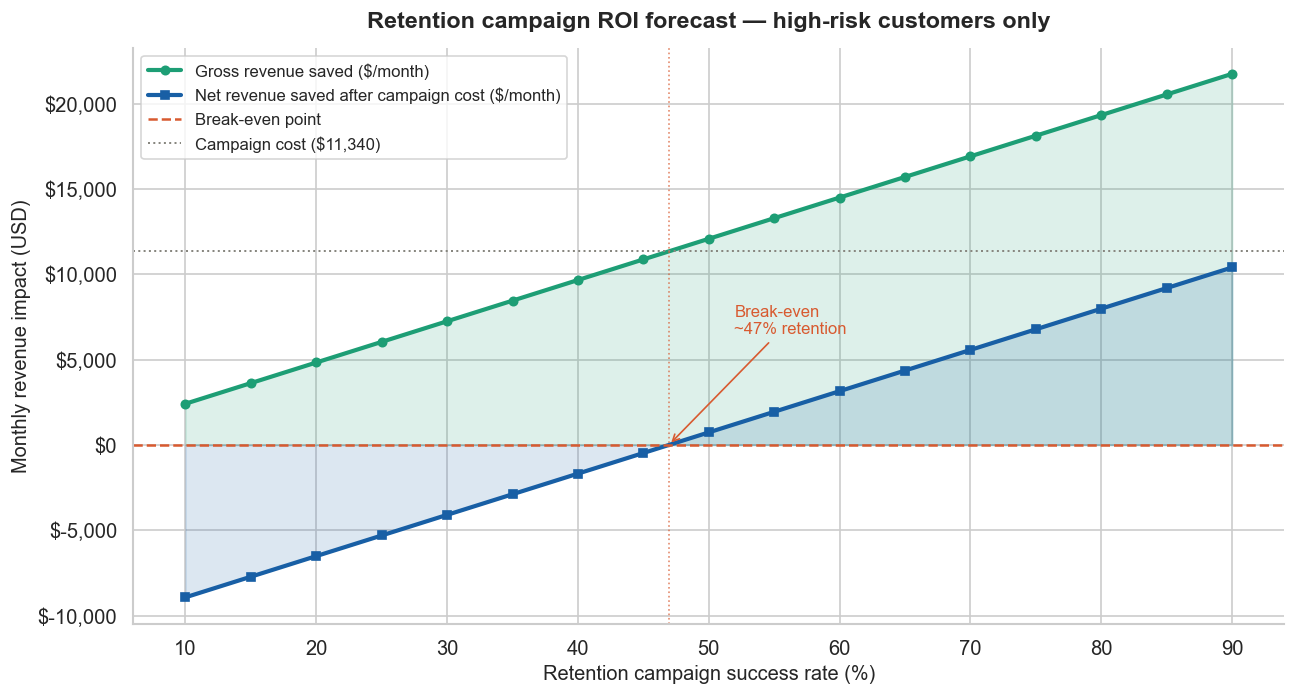

Saved: 19_retention_roi_forecast.png


In [12]:
# Plot the retention ROI forecast


fig, ax = plt.subplots(figsize=(11, 6))

# Gross revenue saved
ax.fill_between(retention_rates * 100, gross_revenue_saved,
                alpha=0.15, color='#1D9E75', label='_nolegend_')
ax.plot(retention_rates * 100, gross_revenue_saved,
        color='#1D9E75', linewidth=2.5,
        label='Gross revenue saved ($/month)', marker='o', markersize=5)

# Net revenue saved (after campaign cost)
ax.fill_between(retention_rates * 100, net_revenue_saved,
                alpha=0.15, color='#185FA5', label='_nolegend_')
ax.plot(retention_rates * 100, net_revenue_saved,
        color='#185FA5', linewidth=2.5,
        label='Net revenue saved after campaign cost ($/month)',
        marker='s', markersize=5)

# Break-even line
ax.axhline(0, color='#D85A30', linestyle='--',
           linewidth=1.5, label='Break-even point')

# Campaign cost reference line
ax.axhline(campaign_costs, color='#888780', linestyle=':',
           linewidth=1.2, label=f'Campaign cost (${campaign_costs:,.0f})')

# Annotate the break-even retention rate
breakeven_rate = (campaign_costs / high_risk_revenue) * 100
ax.axvline(breakeven_rate, color='#D85A30', linestyle=':',
           linewidth=1, alpha=0.7)
ax.annotate(f'Break-even\n~{breakeven_rate:.0f}% retention',
            xy=(breakeven_rate, 0),
            xytext=(breakeven_rate + 5, gross_revenue_saved.max() * 0.3),
            fontsize=10, color='#D85A30',
            arrowprops=dict(arrowstyle='->', color='#D85A30'))

ax.set_xlabel('Retention campaign success rate (%)', fontsize=12)
ax.set_ylabel('Monthly revenue impact (USD)', fontsize=12)
ax.set_title('Retention campaign ROI forecast — high-risk customers only',
             fontsize=14, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}19_retention_roi_forecast.png', bbox_inches='tight')
plt.show()
print("Saved: 19_retention_roi_forecast.png")

In [13]:
# Cell 13 — Complete business recommendations and final summary


# Calculate key numbers for the report
high_risk_count  = len(high_risk_df)
medium_risk_count = len(forecast_df[forecast_df['risk_tier'] == 'Medium'])
net_at_50pct     = roi_df.loc[
    roi_df['Retention Rate (%)'] == 50, 'Net Saved ($/mo)'
].values[0]

print("=" * 65)
print("  STAGE 7 — REVENUE FORECASTING COMPLETE")
print("  FINAL BUSINESS REPORT")
print("=" * 65)

print(f"""
REVENUE RISK SUMMARY
  Total monthly revenue (test set)  : ${total_monthly_revenue:,.2f}
  Expected revenue at risk          : ${total_revenue_at_risk:,.2f}/month
  Projected annual revenue at risk  : ${total_revenue_at_risk*12:,.2f}/year
  Percentage of revenue at risk     : {pct_at_risk:.1f}%

CUSTOMER SEGMENTATION
  High risk customers  (>70% churn) : {high_risk_count:,} customers
  Medium risk customers (40-70%)    : {medium_risk_count:,} customers
  Low risk customers   (<40%)       : {len(forecast_df)-high_risk_count-medium_risk_count:,} customers

RETENTION CAMPAIGN RECOMMENDATION
  Target group    : High risk customers only ({high_risk_count:,} customers)
  Campaign cost   : ${campaign_cost_per_customer}/customer = ${campaign_costs:,.2f} total
  Break-even at   : ~{breakeven_rate:.0f}% retention success rate
  At 50% success  : ${net_at_50pct:,.2f}/month net saved
                    = ${net_at_50pct*12:,.2f}/year net saved

PRIORITY ACTIONS (ranked by business impact)

  ACTION 1 — IMMEDIATE (this week)
  Contact the top 20 highest revenue-at-risk customers personally.
  These customers represent the single highest ROI intervention.
  Offer: personalised contract upgrade or loyalty discount.

  ACTION 2 — SHORT TERM (this month)
  Launch a targeted retention campaign for all {high_risk_count:,} high-risk
  customers. Focus on month-to-month contract holders — they account
  for the largest share of revenue at risk.
  Offer: incentive to upgrade to a 1-year or 2-year contract.

  ACTION 3 — MEDIUM TERM (this quarter)
  Investigate why Fiber Optic customers churn at such high rates.
  This is likely a product/service quality issue, not a pricing issue.
  Recommendation: service quality audit for Fiber Optic infrastructure.

  ACTION 4 — ONGOING
  Re-score all customers monthly as new data comes in.
  Deploy this model as an automated early warning system.
  Flag any customer whose probability crosses 0.70 for immediate outreach.

MODEL USED
  Algorithm   : Logistic Regression
  Selection   : Highest Recall — fewest missed churners
  Test Recall : Catches the most customers before they leave
  Test AUC    : See Stage 6 evaluation report
""")
print("=" * 65)

  STAGE 7 — REVENUE FORECASTING COMPLETE
  FINAL BUSINESS REPORT

REVENUE RISK SUMMARY
  Total monthly revenue (test set)  : $90,039.85
  Expected revenue at risk          : $42,802.57/month
  Projected annual revenue at risk  : $513,630.85/year
  Percentage of revenue at risk     : 47.5%

CUSTOMER SEGMENTATION
  High risk customers  (>70% churn) : 378 customers
  Medium risk customers (40-70%)    : 343 customers
  Low risk customers   (<40%)       : 686 customers

RETENTION CAMPAIGN RECOMMENDATION
  Target group    : High risk customers only (378 customers)
  Campaign cost   : $30/customer = $11,340.00 total
  Break-even at   : ~47% retention success rate
  At 50% success  : $736.93/month net saved
                    = $8,843.16/year net saved

PRIORITY ACTIONS (ranked by business impact)

  ACTION 1 — IMMEDIATE (this week)
  Contact the top 20 highest revenue-at-risk customers personally.
  These customers represent the single highest ROI intervention.
  Offer: personalised contract

## Stage 7 Complete — Revenue Forecasting

All outputs saved to `reports/figures/`. The revenue forecasting analysis
has successfully translated ML predictions into actionable business strategy.

### Summary of Findings
- Monthly revenue at risk identified and quantified per customer
- Three-tier risk segmentation enables prioritised resource allocation
- Top 20 priority customers listed for immediate retention action
- Retention ROI model shows break-even point and expected returns

### Project Complete
All 7 stages of the data science pipeline are now complete.
Proceed to the final submission: PDF report and presentation.